# Analisis exploratorio de datos

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("../data/heart.csv",sep=",")
df_old = df

# Mostrar las primeras filas del DataFrame
print("*** HEAD ***")
display(df.head())
print("="*100)
# Mostrar las dimensiones del DataFrame
print("*** SHAPE ***")
display(df.shape)
print("="*100)
# Mostrar la estructura del DataFrame
print("*** INFO ***")
display(df.info())
print("="*100)
# Mostrar un resumen estadístico de las variables numéricas
print("*** DESC ***")
display(df.describe())
print("="*100)

*** HEAD ***


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


*** SHAPE ***


(918, 12)

*** INFO ***
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


None

*** DESC ***


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Normalizamos datos

In [32]:
display(df["Sex"].unique())
display(df["ChestPainType"].unique())
display(df["FastingBS"].unique())
display(df["RestingECG"].unique())
display(df["ExerciseAngina"].unique())
display(df["ST_Slope"].unique())

cols_category = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

df[cols_category] = df[cols_category].astype('category')

df.info()

<StringArray>
['M', 'F']
Length: 2, dtype: str

<StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str

array([0, 1])

<StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str

<StringArray>
['N', 'Y']
Length: 2, dtype: str

<StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Age             918 non-null    int64   
 1   Sex             918 non-null    category
 2   ChestPainType   918 non-null    category
 3   RestingBP       918 non-null    int64   
 4   Cholesterol     918 non-null    int64   
 5   FastingBS       918 non-null    category
 6   RestingECG      918 non-null    category
 7   MaxHR           918 non-null    int64   
 8   ExerciseAngina  918 non-null    category
 9   Oldpeak         918 non-null    float64 
 10  ST_Slope        918 non-null    category
 11  HeartDisease    918 non-null    int64   
dtypes: category(6), float64(1), int64(5)
memory usage: 48.7 KB


## Valores problematicos

In [33]:
# Nulos
display("Cantidad de nulos")
display(df.isnull().sum())

# Duplicados
display("Cantidad de duplicados")
display(df.duplicated().sum())

# Ceros imposibles
display("Datos biologicamente imposibles")
display((df['Cholesterol'] == 0).sum())
display((df['RestingBP'] == 0).sum())

'Cantidad de nulos'

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

'Cantidad de duplicados'

np.int64(0)

'Datos biologicamente imposibles'

np.int64(172)

np.int64(1)

## Distribuciones

### Numericas

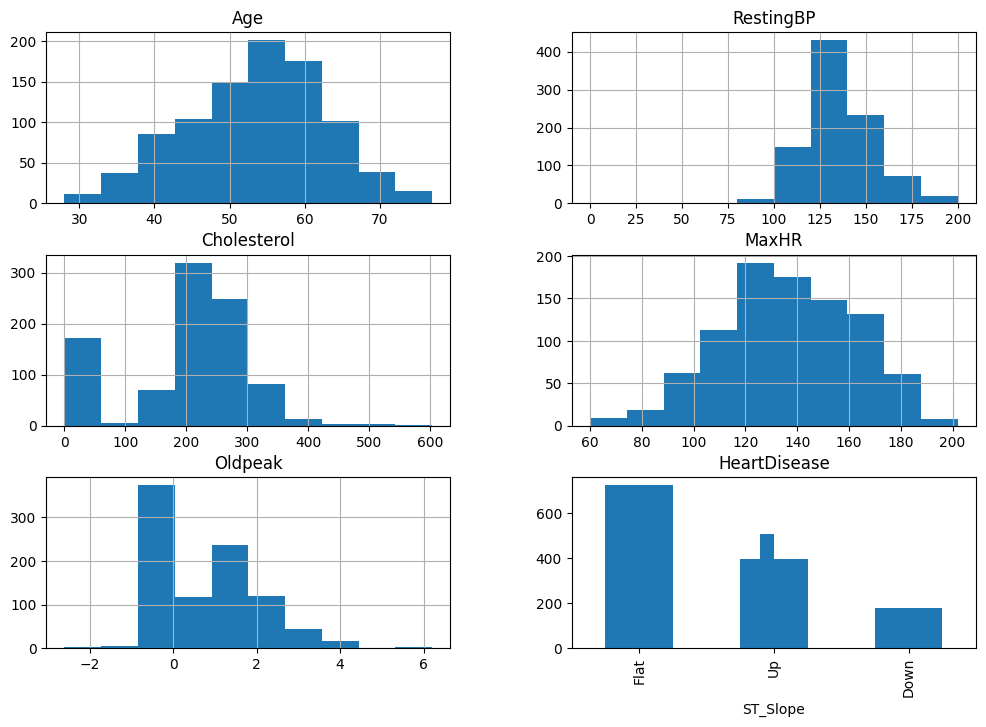

In [34]:
# Numéricas
df.hist(figsize=(12, 8))

# Categóricas
for col in cols_category:
    df[col].value_counts().plot(kind='bar')

Vemos que en general, los datos tiene una ligeramente asimétrica a la izquierda.

Se puede apreciar valores erroneos en Cholesterol y RestingBP

### Categoricas

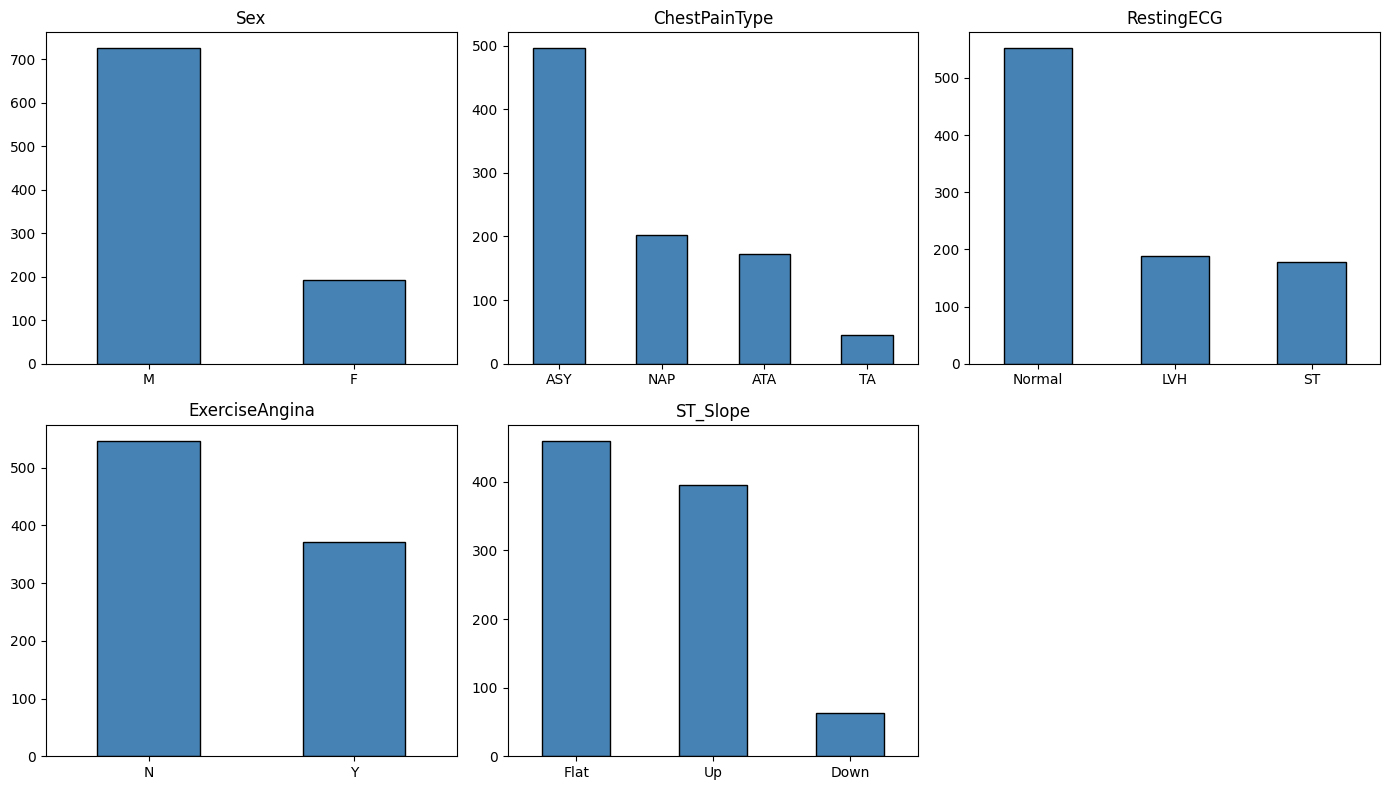

In [35]:
cols_category = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols_category):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].set_visible(False)  # Oculta el subplot vacío (6 espacios, 5 variables)
plt.tight_layout()
plt.savefig('../images/distribuciones_categoricas.png')
plt.show()

## Sex
- Desbalance 78%M / 22%F, posible sesgo histórico de recopilación.
- El modelo aprenderá peor patrones en mujeres por falta de ejemplos.
- **Acción en preprocessing:** ninguna. Vigilar rendimiento del modelo 
  segmentado por sexo en evaluation.py.

## ST_Slope
- 'Down' infrarepresentado (~10%) frente a 'Flat' y 'Up' (~45% cada uno).
- El modelo tendrá pocos ejemplos para aprender el patrón de 'Down'.
- **Acción en preprocessing:** valorar agrupar 'Down' con 'Flat' si no 
  muestra poder predictivo en el paso 7.

## RestingBP
- Valores con 0: imposible biológicamente (presión arterial 0 = muerte clínica).
- Son valores perdidos disfrazados de 0.
- **Acción en preprocessing:** imputar con mediana o media del grupo.

## Cholesterol
- Valores con 0: mismo caso que RestingBP, imposible biológicamente.
- Valores entre 450-600: posibles pero indican hipercolesterolemia severa, 
  no son errores pero sí outliers reales.
- **Acción en preprocessing:** imputar los 0. Mantener los altos salvo evidencia contraria.

## FastingBS
- Desbalance 75%/25%, pero refleja la realidad clínica 
  (la diabetes no es mayoría en población general).
- No es un sesgo de recopilación, es distribución natural.
- **Acción en preprocessing:** ninguna. Monitorizar si el modelo ignora el valor 1.

## MaxHR
- Rango 60-202. El máximo teórico es 220-edad, por lo que 202 
  es extremo pero no imposible en pacientes jóvenes.
- El mínimo de 60 también es límite pero fisiológicamente viable.
- **Acción en preprocessing:** revisar los casos extremos junto con la columna Age 
  antes de decidir si eliminar.

## Oldpeak
- Mide la depresión del segmento ST. Valores negativos son inusuales 
  pero registrados en literatura médica (elevación del ST).
- Max de 6.2 es alto pero documentado en isquemia severa.
- **Acción en preprocessing:** mantener ambos extremos. No son errores.

## ChestPainType
- TA (dolor típico) está muy infrarepresentado con solo ~40 casos.
- ASY domina con ~500 casos, lo cual tiene sentido clínico 
  (muchos infartos son silentes o asintomáticos).
- **Acción en preprocessing:** valorar agrupar TA con NAP si el modelo 
  tiene dificultades con TA, pero solo tras ver su poder predictivo en el paso 7.

## RestingECG
- Desbalance moderado pero las tres clases tienen representación suficiente.
- LVH y ST con ~180 casos cada una es razonable para aprender patrones.
- Distribución coherente con prevalencia clínica real.
- **Acción en preprocessing:** ninguna por ahora.

## HeartDisease
- Valores ~55%/45%
- Dataset balanceado

# Correlaciones

<Axes: >

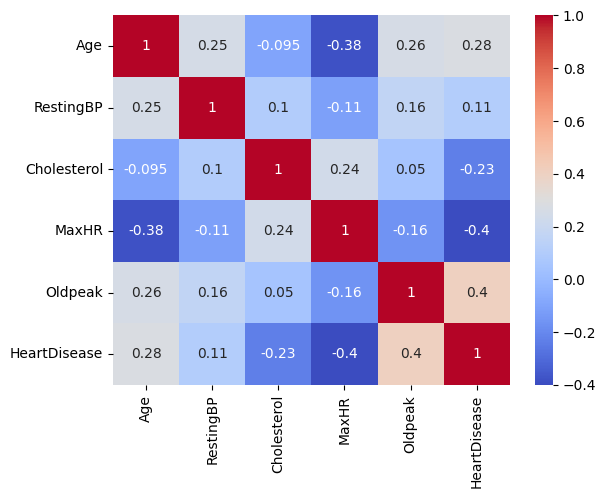

In [36]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

## Correlaciones
- Oldpeak y MaxHR son las variables numéricas más correlacionadas 
  con HeartDisease (0.40 y -0.40).
- No hay multicolinealidad preocupante entre variables independientes.
- Correlaciones bajas no descartan variables: el modelo puede encontrar 
  relaciones no lineales que el heatmap no captura.
- Cholesterol muestra correlación casi nula, posiblemente distorsionada 
  por los valores 0 que serán imputados en preprocessing.

# Relaciones variables vs target

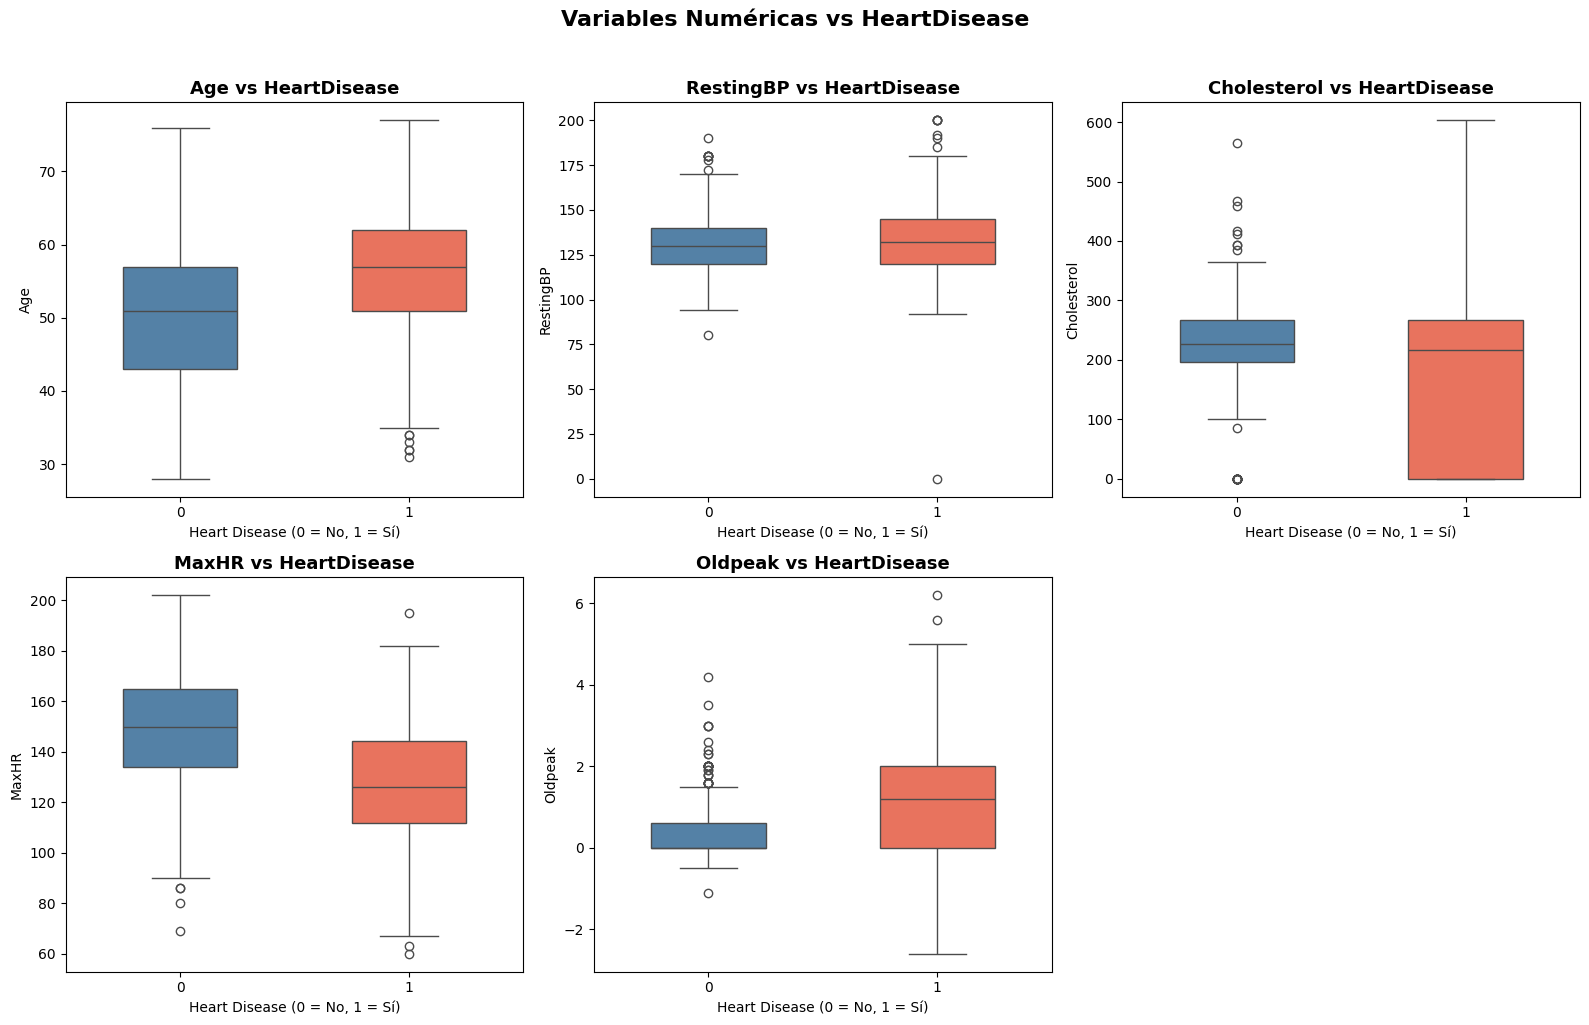

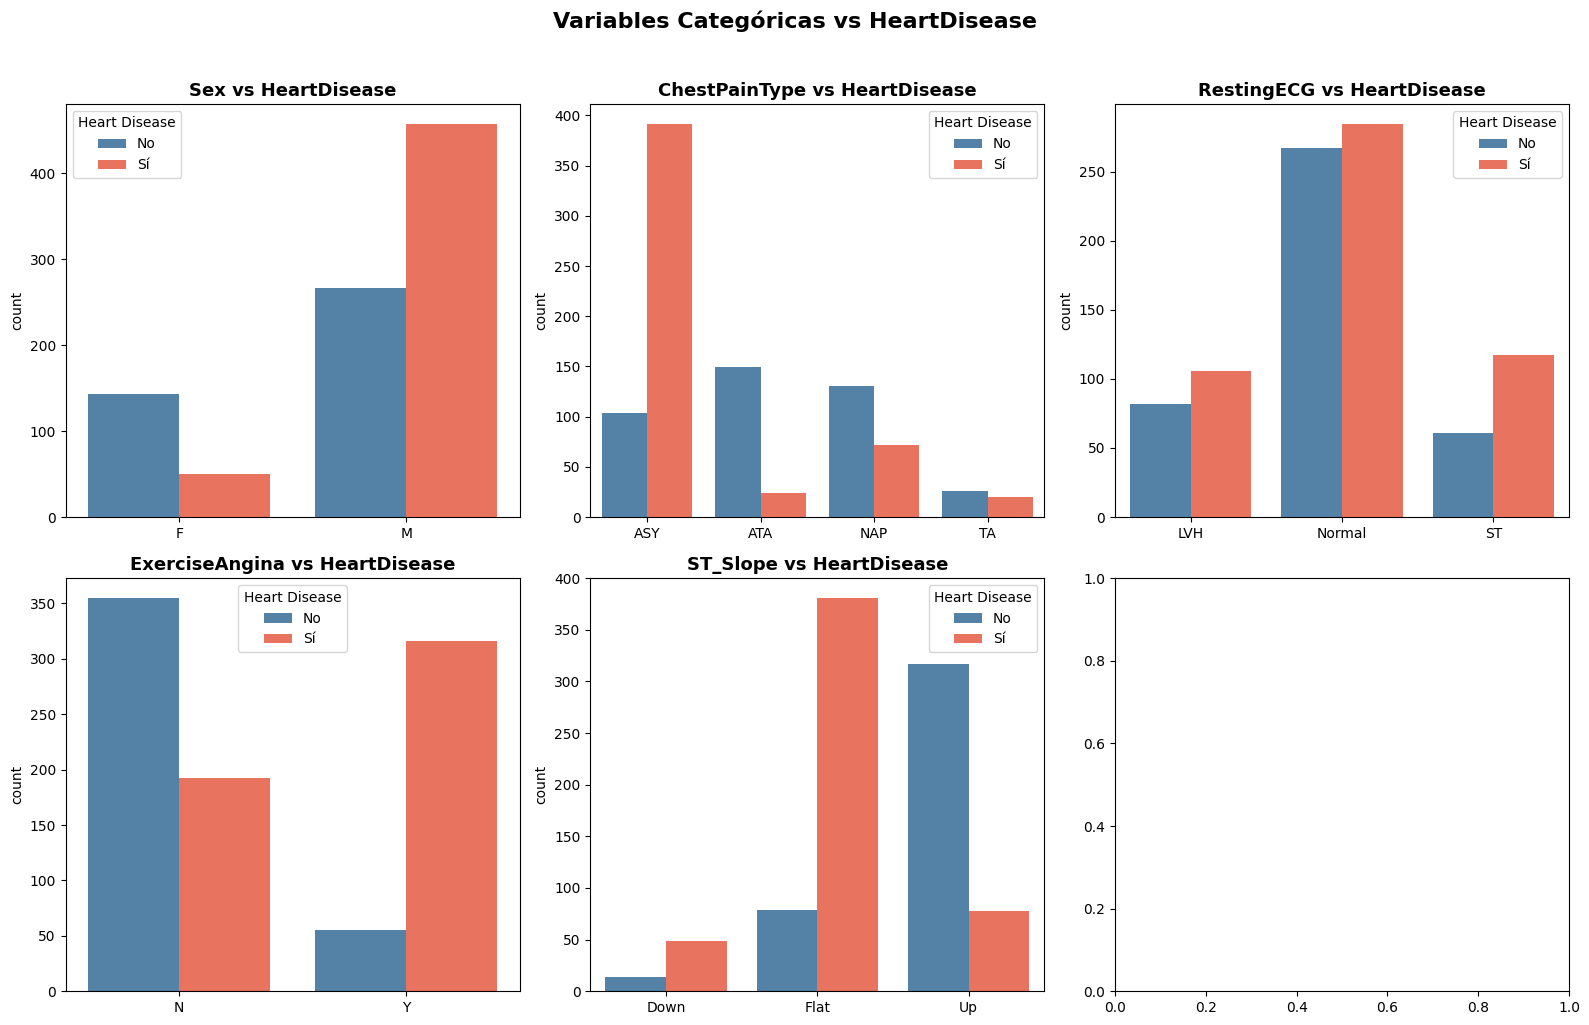

In [38]:
# Numéricas vs HeartDisease
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for i, col in enumerate(num_cols):
    sns.boxplot(x='HeartDisease', y=col, data=df, ax=axes[i],
                hue='HeartDisease',         # ← añadido
                palette={0: 'steelblue', 1: 'tomato'},
                width=0.5,
                legend=False)              # ← añadido
    axes[i].set_title(f'{col} vs HeartDisease', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Heart Disease (0 = No, 1 = Sí)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('Variables Numéricas vs HeartDisease', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/numericas_vs_target.png', bbox_inches='tight')
plt.show()

# Categóricas vs HeartDisease
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_category):
    sns.countplot(x=col, hue='HeartDisease', data=df, ax=axes[i],
                  palette={0: 'steelblue', 1: 'tomato'})
    axes[i].set_title(f'{col} vs HeartDisease', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='Heart Disease', labels=['No', 'Sí'])
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Variables Categóricas vs HeartDisease', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/categoricas_vs_target.png', bbox_inches='tight')
plt.show()